In [1]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/shashank_paper_2/Bhojpuri/merged_data.csv')

In [2]:
data.head()

,label,text
0,1,हमार सबसे बड़ समस्या बा कि सबकुछ के ओवरथिंक कईल
1,1,सबसे खराब उदासी उ उदासी ह जवन रउआ अपना के छिप...
2,1,हमरा त पहिलहीं से मालूम बा कि हम काफ़ी बढ़िया...
3,1,"अब हम उहे नइखीं। हम मान लेब, बहुत गंदगी हमरा ..."
4,1,"हमरा दिमाग में एतना कुछ बा, लेकिन अंत में हम ..."


In [3]:
data_text = data['text']
data_label = data['label']

In [4]:
 import numpy as np
 from sklearn.model_selection import train_test_split
 train, test, labels_train, labels_test = train_test_split(data_text, data_label, test_size=0.25, random_state=42 )

In [5]:
train.head()

3528      रउरा खुश लउकत बानी बाकिर रउरा खुश ना लागे Tha...
4040      राउर पसंद राउर उम्मीद के प्रतिबिंबित करे, राउ...
11794     ट्रम्प 'जवना चीज के मूर्त रूप ह जवन रिपब्लिकन...
447                       केहू नइखे हमरा मरला से बढ़िया बा
4580      हम जहाँ से बानी, उ लोग आपके माथा तब तक पीटत र...
Name: text, dtype: object

In [7]:
import numpy as np
from tensorflow.keras.utils import to_categorical
#classes_list = ["ham","spam"]
#label_index = class_label.apply(classes_list.index)
label_train = to_categorical(np.asarray(labels_train))
label_test = to_categorical(np.asarray(labels_test))

In [8]:
label_train

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [0., 1.],
       [1., 0.]], dtype=float32)

In [9]:
from keras.preprocessing.text import Tokenizer
tk=Tokenizer(filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',lower=True, split=" ")
tk.fit_on_texts(train)
index=tk.word_index
print(index)
x = tk.texts_to_sequences(train)
x1 = tk.texts_to_sequences(test)
print (x)
vocab_size = len(index)
word_index = tk.word_index

{'के': 1, 'से': 2, 'बा': 3, 'में': 4, 'कि': 5, 'ना': 6, 'हम': 7, 'हमरा': 8, 'रउरा': 9, 'आ': 10, 'बानी': 11, 'त': 12, 'लोग': 13, 'खातिर': 14, 'पर': 15, 'एगो': 16, 'हो': 17, 'अपना': 18, 'करे': 19, 'कबो': 20, 'होखे': 21, 'सामान्य': 22, 'ई': 23, 'हमनी': 24, 'होला': 25, 'कर': 26, '”': 27, 'का': 28, 'जवन': 29, 'गइल': 30, 'बस': 31, 'कवनो': 32, 'केहू': 33, 'ऊ': 34, 'बा।': 35, 'जब': 36, 'सबसे': 37, 'ह': 38, 'नइखे': 39, 'बात': 40, 'वाला': 41, 'काहे': 42, 'हमार': 43, 'कुछ': 44, 'रहल': 45, 'उ': 46, 'चाहत': 47, 'ओकरा': 48, 'करत': 49, 'ट्रम्प': 50, 'आपन': 51, 'बढ़िया': 52, 'प्यार': 53, 'जाला': 54, 'जिनिगी': 55, 'बाकिर': 56, 'जा': 57, 'सब': 58, 'रहे': 59, 'बानी।': 60, 'काम': 61, 'करीं': 62, 'ठीक': 63, 'जवना': 64, 'बारे': 65, 'कइल': 66, 'लेकिन': 67, 'हमेशा': 68, 'अगर': 69, 'दिन': 70, 'एक': 71, 'जरूरत': 72, 'सकेला': 73, 'महसूस': 74, 'आदमी': 75, 'दर्द': 76, 'दुख': 77, 'भी': 78, 'गईल': 79, 'तू': 80, 'मत': 81, 'अब': 82, 'करेला': 83, 'ओह': 84, 'एह': 85, 'बाद': 86, 'बहुत': 87, 'एकरा': 88, 'याद': 89, 'राउर':

In [10]:
print(vocab_size)

11209


In [11]:
from keras.preprocessing.sequence import pad_sequences
embedding_vecor_length =32
padded_docs_train = pad_sequences(x, maxlen=embedding_vecor_length, padding='post')
padded_docs_test = pad_sequences(x1, maxlen=embedding_vecor_length, padding='post')


In [12]:
#load pre-trained embedding:
embeddings_index = {}
f = open('/content/drive/My Drive/LSTM_Attention_on_sarcasm_dataset/glove.twitter.27B/glove.twitter.27B.100d.txt', encoding="utf8")
for line in f:
    values = line.split()#This splits each values in a  line with spaces
    word = values[0] # This store the first values which is the word in english
    coefs = np.asarray(values[1:], dtype='float32') # This converts all splitted values from 1 to last(expect first word) into an array
    embeddings_index[word] = coefs # english word = array of numerical values
f.close()
print('Total %s word vectors in Glove 6B 100d.' % len(embeddings_index))

Total 1193514 word vectors in Glove 6B 100d.


In [13]:
# Initialize the weight for each word for the embedding layer. Words not present
# in the dictionary initialized by random value
EMBEDDING_DIM = 100
embedding_matrix = np.random.random((len(word_index) + 1, EMBEDDING_DIM))
#embedding_matrix = (16433, 100) NOTE: It is from uniques words in our tweets
for word, i in word_index.items(): # Selecting word from our tweet unique words list for changing with the values from glove
    embedding_vector = embeddings_index.get(word) # Finding our tweet words in glove and taking its array of 100 values
    if embedding_vector is not None:
#words not found in embedding index will be all-zeros.
        embedding_matrix[i] = embedding_vector

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 32, 100)           1121000   
                                                                 
 conv1d (Conv1D)             (None, 30, 128)           38528     
                                                                 
 max_pooling1d (MaxPooling1  (None, 6, 128)            0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 768)               0         
                                                                 
 dense (Dense)               (None, 256)               196864    
                                                                 
 dense_1 (Dense)             (None, 2)                 514       
                                                        

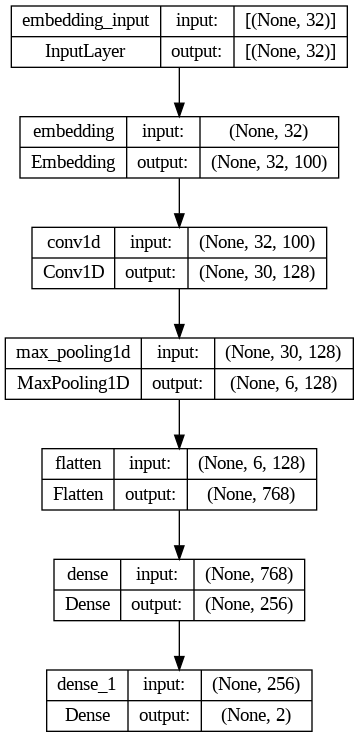

In [15]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Embedding
from keras.layers import Conv1D, GlobalMaxPooling1D, MaxPooling1D
from tensorflow.keras.utils import plot_model
model = Sequential()
model.add(Embedding(input_dim = vocab_size + 1, output_dim = 100, weights=[embedding_matrix], input_length=embedding_vecor_length, trainable=False))
model.add(Conv1D(filters = 128,kernel_size=3, activation='relu'))
model.add(MaxPooling1D(5))
model.add(Flatten())
model.add(Dense(256, activation = 'relu'))
model.add(Dense(2, activation = 'softmax'))
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
model.summary()
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)


In [16]:
model.fit(padded_docs_train, label_train, validation_data = (padded_docs_test, label_test),
          epochs=100,batch_size=100, verbose=2)

Epoch 1/100
91/91 - 5s - loss: 0.5648 - accuracy: 0.6969 - val_loss: 0.4969 - val_accuracy: 0.7550 - 5s/epoch - 54ms/step
Epoch 2/100
91/91 - 0s - loss: 0.4330 - accuracy: 0.7928 - val_loss: 0.4410 - val_accuracy: 0.7902 - 356ms/epoch - 4ms/step
Epoch 3/100
91/91 - 0s - loss: 0.3630 - accuracy: 0.8343 - val_loss: 0.4191 - val_accuracy: 0.8065 - 415ms/epoch - 5ms/step
Epoch 4/100
91/91 - 0s - loss: 0.3365 - accuracy: 0.8486 - val_loss: 0.4106 - val_accuracy: 0.8062 - 340ms/epoch - 4ms/step
Epoch 5/100
91/91 - 0s - loss: 0.2667 - accuracy: 0.8858 - val_loss: 0.4353 - val_accuracy: 0.8085 - 335ms/epoch - 4ms/step
Epoch 6/100
91/91 - 0s - loss: 0.2231 - accuracy: 0.9068 - val_loss: 0.4204 - val_accuracy: 0.8128 - 342ms/epoch - 4ms/step
Epoch 7/100
91/91 - 0s - loss: 0.1849 - accuracy: 0.9288 - val_loss: 0.4933 - val_accuracy: 0.7989 - 365ms/epoch - 4ms/step
Epoch 8/100
91/91 - 0s - loss: 0.1463 - accuracy: 0.9424 - val_loss: 0.4855 - val_accuracy: 0.8092 - 342ms/epoch - 4ms/step
Epoch 9/10

In [17]:
predictions_test_cnn = model.predict(padded_docs_test)
predictions_testcnn1 = np.zeros_like(predictions_test_cnn)
predictions_testcnn1[np.arange(len(predictions_test_cnn)), predictions_test_cnn.argmax(1)] = 1
from sklearn.metrics import classification_report
print(classification_report(label_test,predictions_testcnn1))


94/94 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1811
           1       0.70      0.87      0.78      1197

   micro avg       0.80      0.80      0.80      3008
   macro avg       0.80      0.81      0.80      3008
weighted avg       0.82      0.80      0.80      3008
 samples avg       0.80      0.80      0.80      3008



In [ ]:
import time
start_time = time.time()
predictions_test_cnn = model.predict(padded_docs_test)
print("--- %s seconds ---" % (time.time() - start_time))

--- 0.3469421863555908 seconds ---
